### Columns (8 columns)
**Transaction ID** : A unique identifier for each transaction.,  
**Item** : The name of the item purchased.,  
**Quantity**: The quantity of the item purchased.,  
**Price Per Unit** : The price of a single unit of the item.,  
**Total Spent** : The total amount spent on the transaction.,  
**Payment Method** : The method of payment used.,   
**Location** : The location where the transaction occurred.,   
**Transaction Date** : The date of the transaction., 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ☕ Plan d’analyse condensé — Projet “Coffee Sales”
## 🎯 Objectif du projet

### Analyser les ventes d’un café afin de :

- comprendre les performances commerciales,
- identifier les produits les plus rentables,
- analyser le comportement des clients,
- extraire des insights business utiles.


###  Analyse globale des ventes
Questions
- Quel est le chiffre d’affaires total ?
- Combien de transactions ?
- Quel est le panier moyen ?


###  Analyse des produits
Questions
- Quels produits se vendent le plus ?
- Quels produits génèrent le plus de revenus ?
- Les produits les plus vendus sont-ils les plus rentables ?


### Analyse des modes de paiement
Questions
- Quel mode de paiement est le plus utilisé ?
- Quel mode génère le plus de revenus ?


### Analyse géographique (Location) : Mode de consommation
Questions
- Quel mode de consommation performe le mieux ?
- Quel mode de consommation attire le plus de clients ?


###  Analyse temporelle
Questions
- Comment évoluent les ventes dans le temps ?
- Existe-t-il des pics de consommation ?  

### Conclusion finale
Résumer : 

- principaux produits performants,
- modes de paiement dominants,
- tendances temporelles,
- qualité des données.

Ajouter
- limites du projet,
- pistes d’amélioration futures.  


In [2]:
devise = "€"

In [3]:
df = pd.read_csv("cleaned_cafe_sales.csv", parse_dates=["Transaction Date"])
cafe = df.copy()

In [4]:
cafe.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
cafe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9942 entries, 0 to 9941
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9942 non-null   object        
 1   Item              9942 non-null   object        
 2   Quantity          9942 non-null   float64       
 3   Price Per Unit    9942 non-null   float64       
 4   Total Spent       9942 non-null   float64       
 5   Payment Method    9942 non-null   object        
 6   Location          9942 non-null   object        
 7   Transaction Date  9485 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 621.5+ KB


In [6]:
# conversion de la colonne Quantity en int 
cafe["Quantity"] = cafe["Quantity"].astype("int")

<class 'pandas.core.series.Series'>
RangeIndex: 9942 entries, 0 to 9941
Series name: Quantity
Non-Null Count  Dtype
--------------  -----
9942 non-null   int32
dtypes: int32(1)
memory usage: 39.0 KB


In [7]:
# Affichage des années auxquelles les études se basent 
cafe["Transaction Date"].dt.year.unique()

array([2023.,   nan])

Cette étude se base sur les ventes de café en 2023.

In [8]:
# Nombre de transactions dans le dataset
print(f"Pour 2023, on va étudier {cafe.shape[0]} transactions.")

Pour 2023, on va étudier 9942 transactions.


In [9]:
# Nombre de transactions, chiffre d'affaire total, panier moyen
transaction_count = cafe.shape[0]
ca_total = cafe["Total Spent"].sum()
panier_moyen = np.round(cafe["Total Spent"].mean(), 2)

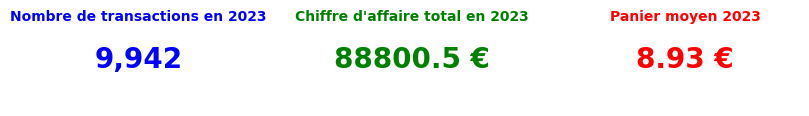

In [10]:
# Affichage du nombre de transactions, chiffre d'affaire et panier moyen
fig = plt.figure(figsize=(10, 1))

ax1 = fig.add_subplot(131)
ax1.text(x=0.5, y=0.5, s = f"{transaction_count:,.0f}", fontsize=20, fontweight='bold', ha='center', color="blue")
ax1.set_title("Nombre de transactions en 2023", fontsize=10, fontweight='bold', color="blue")
ax1.axis('off')

ax2 = fig.add_subplot(132)
ax2.text(x=0.5, y=0.5, s= f"{np.round(ca_total, 2)} {devise}", fontsize=20, fontweight="bold", ha="center", color="green")
ax2.set_title("Chiffre d'affaire total en 2023", fontsize=10, fontweight="bold", color="green")
ax2.axis("off")

ax3 = fig.add_subplot(133)
ax3.text(x=0.5, y=0.5, s= f"{panier_moyen} {devise}", fontsize=20, fontweight="bold", ha="center", color="red")
ax3.set_title("Panier moyen 2023", fontsize=10, fontweight="bold", color="red")
ax3.axis("off")

plt.show()

L’analyse des KPI montre un total de 9 942 transactions générant un chiffre d’affaires de 88 800 €. Le panier moyen de 8,93 € indique une consommation à faible valeur unitaire, suggérant un modèle basé sur la fréquence d’achat plutôt que sur des transactions élevées. Cette structure met en évidence une opportunité d’augmentation du revenu via des stratégies d’upselling et de cross-selling.

In [11]:
# Produits vendus, methodes de payements, Lieux de ventes
produits_vendus = cafe["Item"].value_counts().sort_values(ascending=False)
payments_method = cafe["Payment Method"].value_counts().sort_values(ascending=False)
lieux_vente = cafe["Location"].value_counts().sort_values(ascending=False)

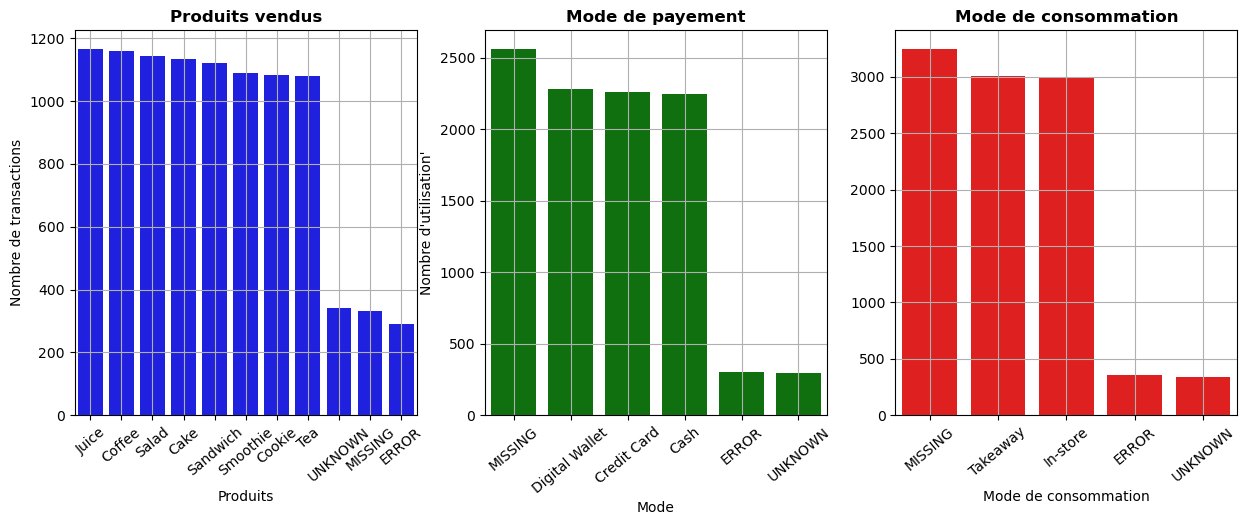

In [12]:
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

sns.barplot(x=produits_vendus.index, y=produits_vendus.values, ax=ax1, color="blue")
ax1.set_title("Produits vendus", fontweight="bold")
ax1.set_xlabel("Produits")
ax1.set_ylabel("Nombre de transactions")
ax1.tick_params(axis="x", rotation=40)
ax1.grid("both")

sns.barplot(x=payments_method.index, y=payments_method.values, ax=ax2, color="green")
ax2.set_title("Mode de payement", fontweight="bold")
ax2.set_xlabel("Mode")
ax2.set_ylabel("Nombre d'utilisation'")
ax2.tick_params(axis="x", rotation=40)
ax2.grid("both")

sns.barplot(x=lieux_vente.index, y=lieux_vente.values, ax=ax3, color="red")
ax3.set_title("Mode de consommation", fontweight="bold")
ax3.set_xlabel("Mode de consommation")
ax3.set_ylabel("")
ax3.tick_params(axis="x", rotation=40)
ax3.grid("both")

plt.show()

# Analyse des produits

- Quels produits se vendent le plus ?
- Quels produits génèrent le plus de revenu ?
- Les produits les plus vendus sont-ils les plus rentables ?

In [13]:
# Produit le plus vendu
item_count = cafe["Item"].value_counts().sort_values(ascending=False)
print(f"Produit plus vendu : {item_count.index[0]}  ({item_count.values[0]} fois).")

# Produit générant le plus de revenu
avec_plus_de_revenu = cafe.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
print(f"Produit plus de revenu : {avec_plus_de_revenu.index[0]} ({avec_plus_de_revenu.values[0]} {devise}).")

Produit plus vendu : Juice  (1167 fois).
Produit plus de revenu : Salad (17315.0 €).


In [14]:
# Prix de chaque produit
prix_unitaires = cafe.groupby("Item")["Price Per Unit"].first()
prix_unitaires = prix_unitaires.drop(["MISSING", "ERROR", "UNKNOWN"], errors="ignore").sort_values(ascending=False)
prix_unitaires

Item
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Cake        3.0
Juice       3.0
Coffee      2.0
Tea         1.5
Cookie      1.0
Name: Price Per Unit, dtype: float64

> Bien que le jus soit le produit le plus vendu (prix unitaire = 3), la salade génère le chiffre d’affaires le plus élevé (prix unitaire = 5), ce qui met en évidence une différence entre les préférences des clients et les principaux moteurs de revenus.

> Le classement des produits selon le volume des ventes diffère du classement basé sur le chiffre d’affaires. Les produits les plus rentables sont principalement ceux ayant un prix unitaire plus élevé, ce qui indique que le chiffre d’affaires est davantage influencé par le prix des articles que par le volume des ventes.


In [15]:
cafe_ex = cafe[~((cafe["Item"] == "MISSING") | (cafe["Item"] =="ERROR") | (cafe["Item"] == "UNKNOWN"))]

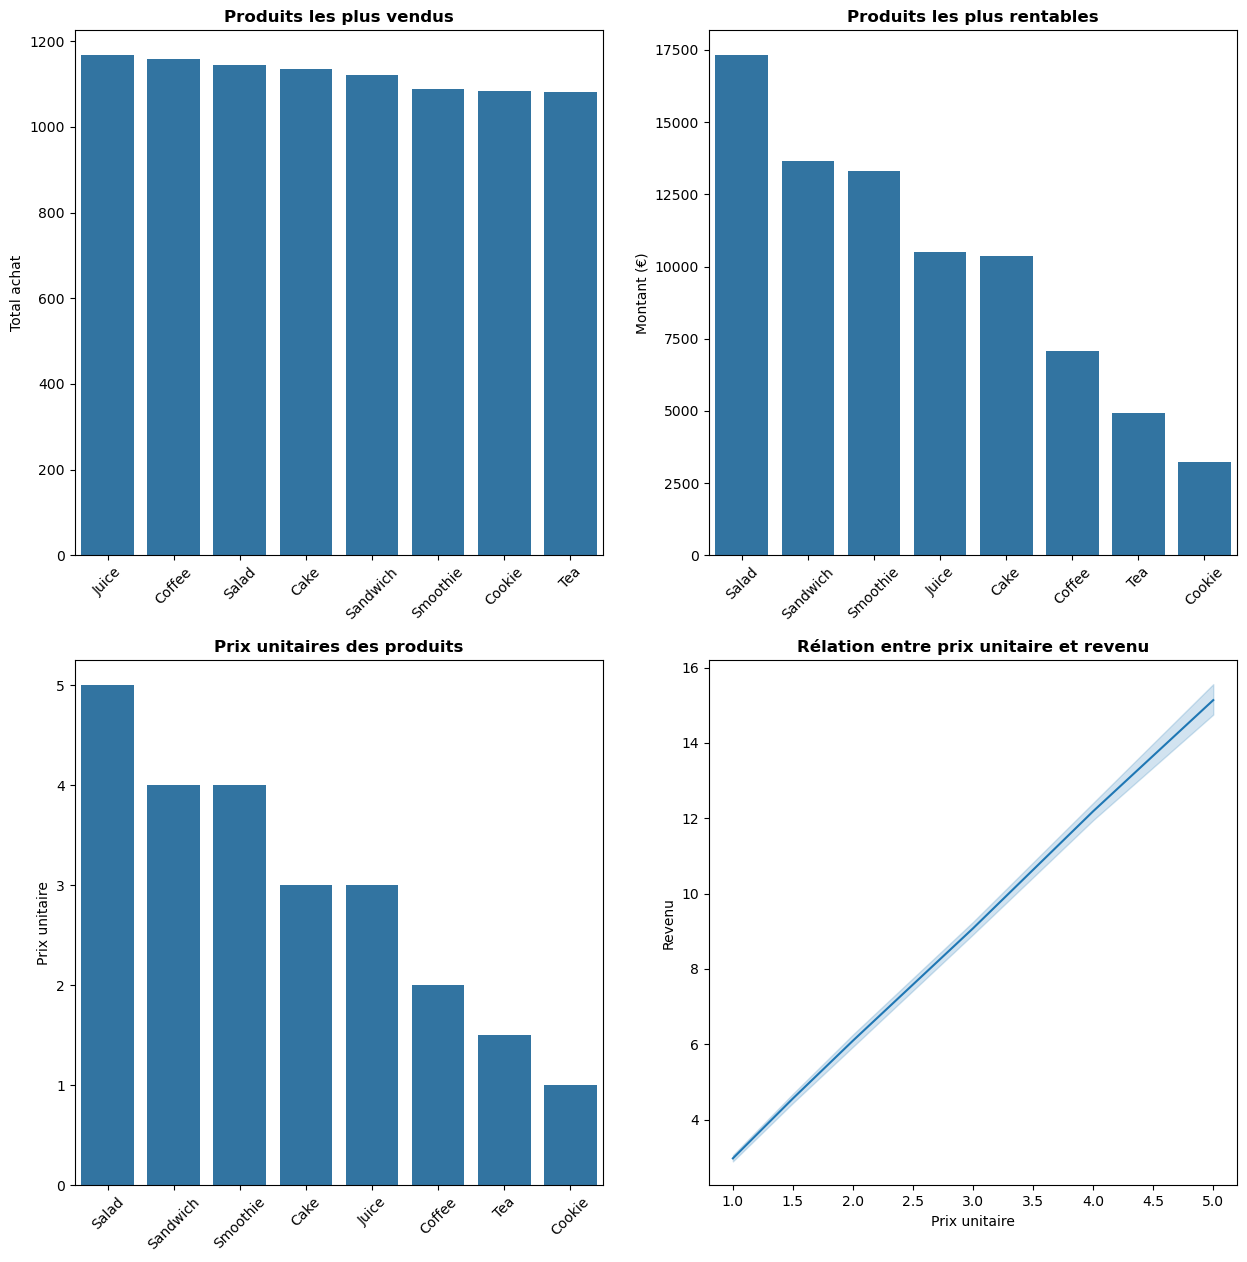

In [16]:
fig = plt.figure(figsize=(15, 15))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

sns.barplot(x=item_count.head(8).index, y=item_count.head(8).values, ax=ax1)
ax1.set_title("Produits les plus vendus", fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("Total achat")
ax1.tick_params(axis="x", rotation=45)

sns.barplot(x=avec_plus_de_revenu.head(8).index, y=avec_plus_de_revenu.head(8).values, ax=ax2)
ax2.set_title("Produits les plus rentables", fontweight="bold")
ax2.set_xlabel("")
ax2.set_ylabel(ylabel= f"Montant ({devise})")
ax2.tick_params(axis="x", rotation=45)

sns.barplot(x=prix_unitaires.index, y=prix_unitaires.values, ax=ax3)
ax3.set_title("Prix unitaires des produits", fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("Prix unitaire")
ax3.tick_params(axis="x", rotation=45)

sns.lineplot(data=cafe_ex, x="Price Per Unit", y="Total Spent", ax=ax4)
ax4.set_title("Rélation entre prix unitaire et revenu", fontweight="bold")
ax4.set_xlabel("Prix unitaire")
ax4.set_ylabel("Revenu")

plt.show()

In [17]:
prix_unitaires.corr(avec_plus_de_revenu.head(8))

0.9987982531963466

> Bien que la corrélation entre le prix unitaire et le chiffre d’affaires soit extrêmement élevée (r = 0.9988), cette relation est en partie attendue puisque le chiffre d’affaires total dépend directement du prix des produits et des quantités vendues.


# Analyse des modes de paiement

- Quel mode de paiement est le plus utilisé ?
- Quel mode génère le plus de revenus ?

In [18]:
# Mode de paiement le plus utilisé
payment_clean = cafe[
    ~cafe["Payment Method"].isin(["MISSING", "UNKNOWN", "ERROR"])
]
mode_de_paiement = payment_clean["Payment Method"].value_counts()
mode_de_paiement

Payment Method
Digital Wallet    2280
Credit Card       2260
Cash              2244
Name: count, dtype: int64

In [19]:
# Méthode de paiement qui donne le plus de revenu
revenue_per_method = cafe.groupby("Payment Method")["Total Spent"].sum().sort_values(ascending=False)
revenue_per_method

Payment Method
MISSING           22594.0
Credit Card       20386.5
Digital Wallet    20362.5
Cash              20340.5
ERROR              2622.5
UNKNOWN            2494.5
Name: Total Spent, dtype: float64

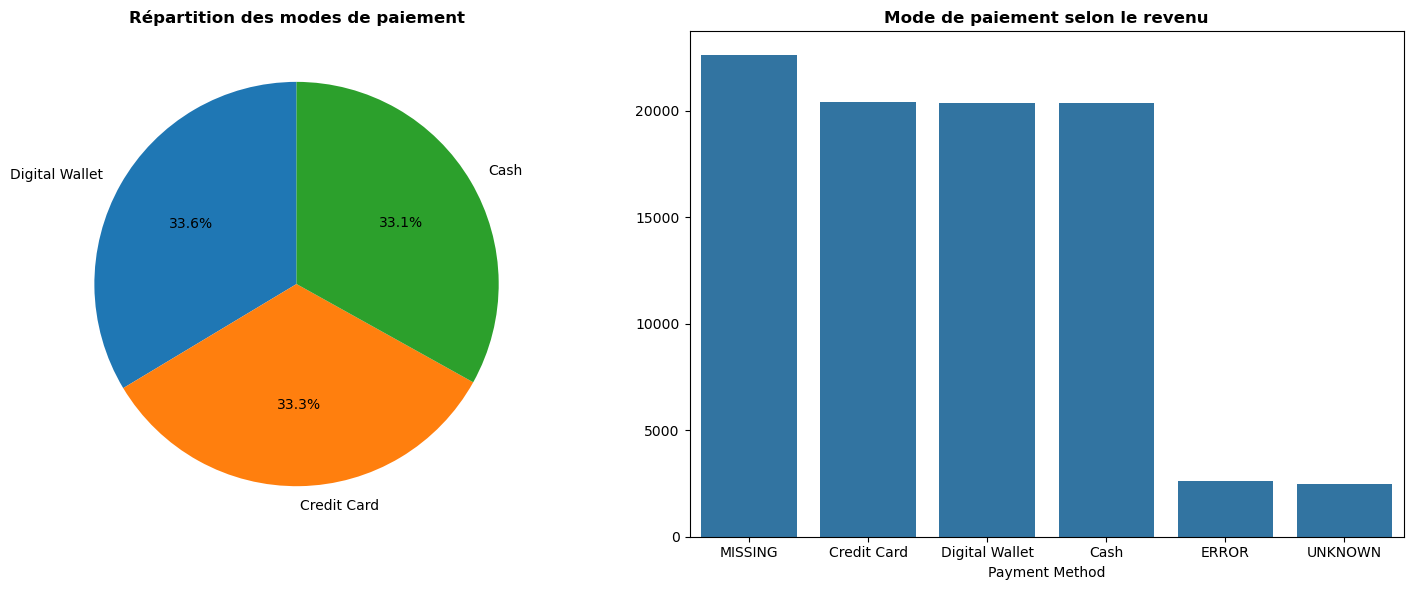

In [20]:
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121)
ax1.pie(
    mode_de_paiement.values,
    labels=mode_de_paiement.index,
    autopct='%1.1f%%',
    startangle=90
)
ax1.set_title("Répartition des modes de paiement", fontweight='bold')


ax2 = fig.add_subplot(122)
sns.barplot(x=revenue_per_method.index, y=revenue_per_method.values, ax=ax2)
ax2.set_title("Mode de paiement selon le revenu", fontweight="bold")

plt.tight_layout()
plt.show()

>La répartition des modes de paiement est remarquablement équilibrée entre Digital Wallet, Credit Card et Cash, chacun représentant environ un tiers du nombre total de transactions.

>L’analyse montre que Credit Card, Digital Wallet et Cash génèrent des revenus presque identiques, ce qui suggère une utilisation équilibrée des différents modes de paiement par les clients. Cependant, une part importante du chiffre d’affaires est associée à des informations de paiement manquantes ou invalides, mettant en évidence un problème de qualité des données susceptible d’affecter la fiabilité des analyses liées aux modes de paiement.

# Analyse géographique (mode de consommation)
- Quel mode de consommation performe le mieux ?
- Quel mode de consommation attire le plus de clients ?

In [21]:
location_rep = cafe["Location"].value_counts().reset_index()
print("Mode de consommation")
display(location_rep)

Mode de consommation


,Location,count
0,MISSING,3249
1,Takeaway,3004
2,In-store,2998
3,ERROR,355
4,UNKNOWN,336


In [22]:
location_rep_clean = location_rep[~location_rep["Location"].isin(["MISSING", "ERROR", "UNKNOWN"])]
print("Mode de consommation")
display(location_rep_clean)

Mode de consommation


,Location,count
1,Takeaway,3004
2,In-store,2998


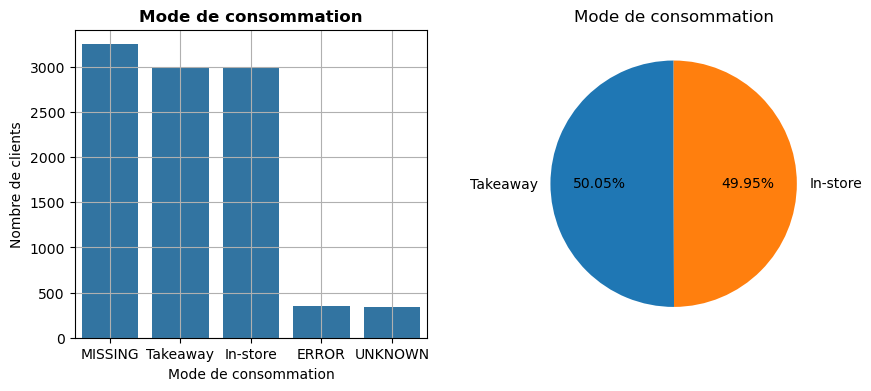

In [23]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
sns.barplot(data=location_rep, x="Location", y="count", ax=ax1)
ax1.set_title("Mode de consommation", fontweight="bold")
ax1.set_xlabel("Mode de consommation")
ax1.set_ylabel("Nombre de clients")
ax1.grid()

ax2 = fig.add_subplot(122)
ax2.pie(
    x=location_rep_clean["count"],
    labels = location_rep_clean["Location"],
    autopct='%1.2f%%',
    startangle=90  
)
ax2.set_title("Mode de consommation")

plt.show()

Les clients sont **quasi parfaitement partagés** entre *emporter* et *sur place*, avec un ecart de seulement 6.  


**Conclusion** : Le café n'a aucune préférence dominante visible dans les données - le comportement des clients est pratiquement équilibré entre les deux options.

In [24]:
# Le mode de consommation le plus rentable
mode_conso_rent = cafe.groupby("Location")["Total Spent"].sum().sort_values(ascending=False).reset_index()
mode_conso_rent

,Location,Total Spent
0,MISSING,29263.5
1,In-store,27073.0
2,Takeaway,26447.5
3,ERROR,3230.5
4,UNKNOWN,2786.0


In [25]:
mode_conso_rent_clean = mode_conso_rent[~mode_conso_rent["Location"].isin(["MISSING", "ERROR", "UNKNOWN"])]
print("Mode de consommation les plus rentables")
display(mode_conso_rent_clean)

Mode de consommation les plus rentables


,Location,Total Spent
1,In-store,27073.0
2,Takeaway,26447.5


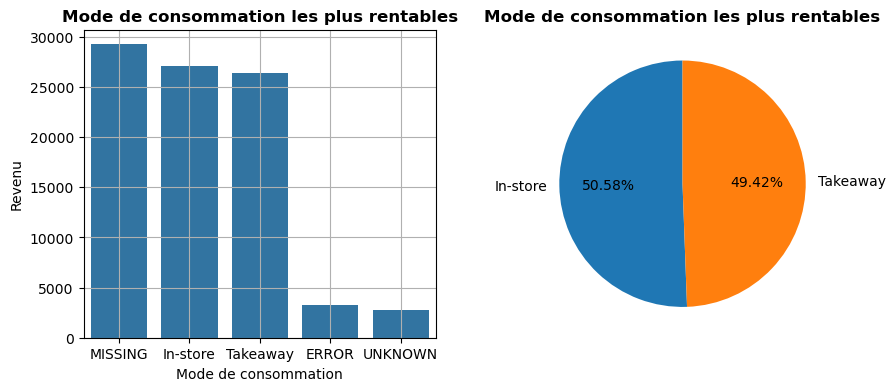

In [26]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
sns.barplot(data=mode_conso_rent, x="Location", y="Total Spent", ax=ax1)
ax1.set_title("Mode de consommation les plus rentables", fontweight="bold")
ax1.set_xlabel("Mode de consommation")
ax1.set_ylabel("Revenu")
ax1.grid()

ax2 = fig.add_subplot(122)
ax2.pie(
    x=mode_conso_rent_clean["Total Spent"],
    labels = mode_conso_rent_clean["Location"],
    autopct='%1.2f%%',
    startangle=90  
)
ax2.set_title("Mode de consommation les plus rentables", fontweight="bold")

plt.show()

Quel que soit le mode de consommation, le revenu selon le mode est le même partout avec **sur place (27073.0) et à emporter (26447.5)**. Cela nous permet de dire que les deux modes sont importants pour le bon-fonctionnement du café.

# Analyse temporelle
- Comment évolue les ventes dans le temps ?
- Etudier le niveau d'affluence selon le mois.
- Quel est le mois le plus rentable ?
- Etudier le niveau d'affluence selon le jour ?
- Quel est le jour le plus rentable ?

In [27]:
cafe.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [28]:
cafe["Month"] = cafe["Transaction Date"].dt.month
cafe["Month Name"] = cafe["Transaction Date"].dt.month_name()
cafe["Day"] = cafe["Transaction Date"].dt.day
cafe["Day Name"] = cafe["Transaction Date"].dt.day_name()
cafe.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Month Name,Day,Day Name
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,9.0,September,8.0,Friday
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,5.0,May,16.0,Tuesday
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,7.0,July,19.0,Wednesday
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,4.0,April,27.0,Thursday
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,6.0,June,11.0,Sunday


In [29]:
# Evolution des ventes dans le temps
rev_per_day = cafe.groupby(["Day"])["Total Spent"].sum().reset_index()
rev_per_day.head()

,Day,Total Spent
0,1.0,2584.5
1,2.0,2682.0
2,3.0,2522.0
3,4.0,2759.0
4,5.0,2607.0


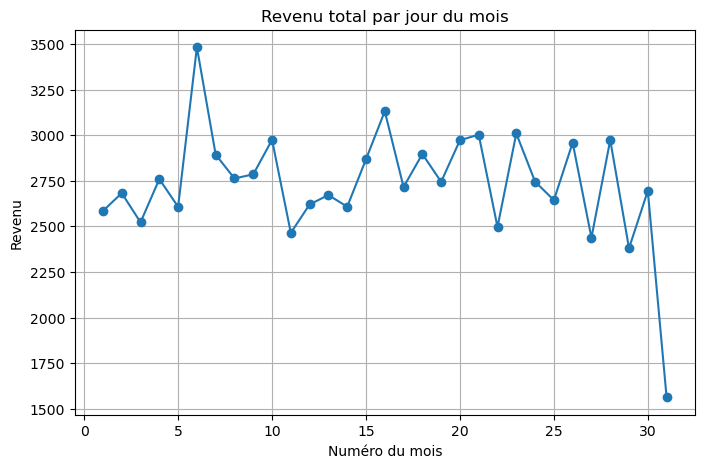

In [30]:
fig = plt.figure(figsize=(8, 5))
plt.plot(rev_per_day["Day"], rev_per_day["Total Spent"], marker="o")
plt.xlabel("Numéro du mois")
plt.ylabel("Revenu")
plt.title("Revenu total par jour du mois")
plt.grid()

Les revenus journaliers sont globalement stables avec des fluctuations importantes et quelques pics isolés, sans tendance claire liée au jour du mois.

In [31]:
# Affluence selon le mois
affluence_mois = cafe["Month Name"].value_counts().reset_index()

print("Le mois le plus affluent")
display(affluence_mois)

Le mois le plus affluent


,Month Name,count
0,October,834
1,March,822
2,June,816
3,January,812
4,August,798
5,July,788
6,December,788
7,September,783
8,November,782
9,May,770


In [32]:
# Le mois le plus rentable
revenu_mois = cafe.groupby("Month Name")["Total Spent"].sum().reset_index()
revenu_mois.sort_values(by=["Total Spent"], inplace=True, ascending=False)
revenu_mois = revenu_mois.reset_index()
revenu_mois.drop(columns=["index"], inplace=True)
display(revenu_mois)

,Month Name,Total Spent
0,June,7350.0
1,October,7295.0
2,January,7219.0
3,March,7190.5
4,April,7168.0
5,December,7153.0
6,August,7049.5
7,November,6957.0
8,May,6916.5
9,July,6876.5


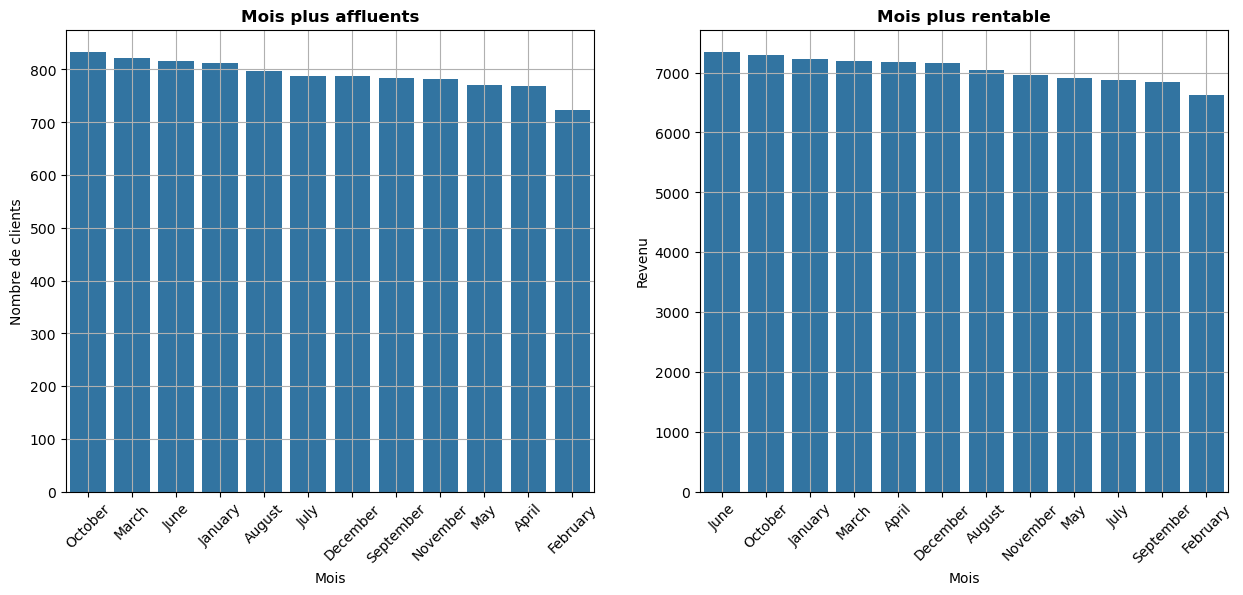

In [33]:
# Visualisation
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

sns.barplot(data=affluence_mois, x="Month Name", y="count", ax=ax1)
ax1.set_title("Mois plus affluents", fontweight="bold")
ax1.set_xlabel("Mois")
ax1.set_ylabel("Nombre de clients")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="both")

sns.barplot(data=revenu_mois, x="Month Name", y="Total Spent", ax=ax2)
ax2.set_title("Mois plus rentable", fontweight="bold")
ax2.set_xlabel("Mois")
ax2.set_ylabel("Revenu")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="both")

plt.show()

- On observe que le mois avec la plus grande affluence est **Octobre** qui est en seconde position sur le classement des mois les plus rentable. 
- Et le mois de février est celui le moins affluent et le moins rentable.
- Le mois le plus rentable est le mois de juin.

In [34]:
# Affluence selon le jour
affluence_jour = cafe["Day Name"].value_counts().reset_index()

print("Le jour le plus affluent")
display(affluence_jour)

Le jour le plus affluent


,Day Name,count
0,Friday,1379
1,Sunday,1376
2,Monday,1375
3,Thursday,1373
4,Saturday,1347
5,Wednesday,1329
6,Tuesday,1306


In [35]:
# Le jour le plus rentable
revenu_jour = cafe.groupby("Day Name")["Total Spent"].sum().reset_index()
revenu_jour.sort_values(by=["Total Spent"], inplace=True, ascending=False)
revenu_jour = revenu_jour.reset_index()
revenu_jour.drop(columns=["index"], inplace=True)
display(revenu_jour)

,Day Name,Total Spent
0,Thursday,12374.0
1,Friday,12307.5
2,Sunday,12269.5
3,Monday,12124.5
4,Tuesday,12027.5
5,Saturday,11941.5
6,Wednesday,11598.5


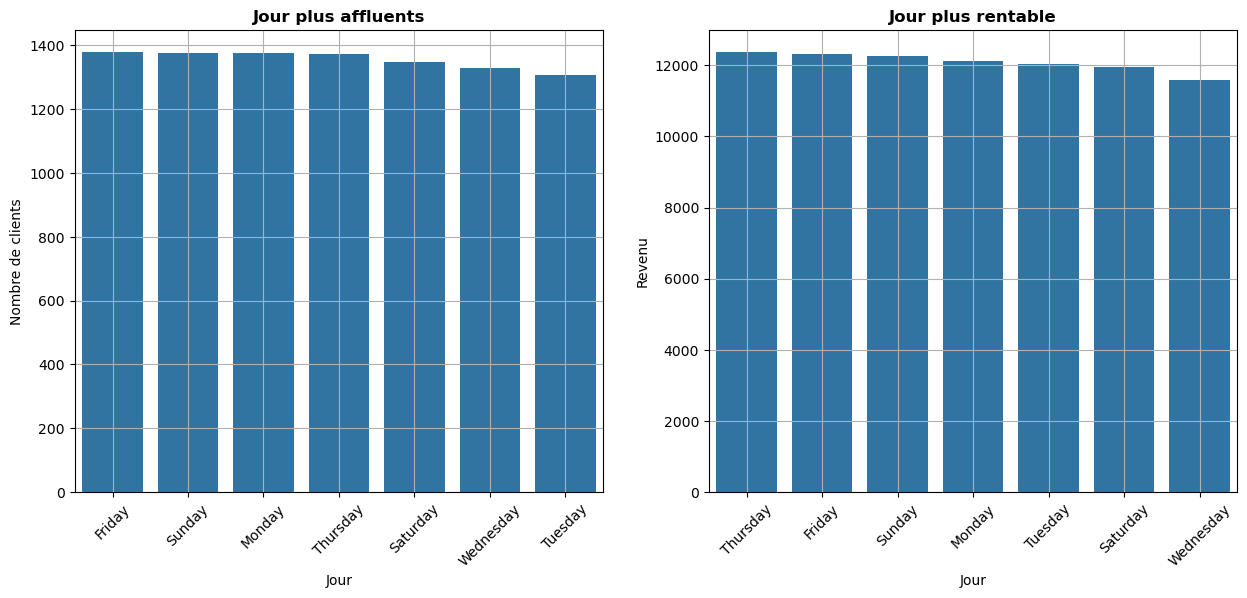

In [36]:
# Visualisation
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

sns.barplot(data=affluence_jour, x="Day Name", y="count", ax=ax1)
ax1.set_title("Jour plus affluents", fontweight="bold")
ax1.set_xlabel("Jour")
ax1.set_ylabel("Nombre de clients")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="both")

sns.barplot(data=revenu_jour, x="Day Name", y="Total Spent", ax=ax2)
ax2.set_title("Jour plus rentable", fontweight="bold")
ax2.set_xlabel("Jour")
ax2.set_ylabel("Revenu")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="both")

plt.show()

- Le jour le plus affluent est **vendredi** qui est en deuxième position parmi les jours les plus rentables. 
- Le jour le plus rentable est **Jeudi**.

## Conclusion générale

- **Année d'étude : 2023**
- **Nombre de transactions étudiées : 9942 transactions**
- **Chiffre d'affaires total en 2023 : 88800.5 €**
- **Panier moyen en 2023 : 8.93 €**
- **Produits vendus : Jus, Café, Salade, Gâteau, Sandwich, Smoothie, Cookie & Thé**
- **Moyens de paiement utilisés :**
    - **Digital Wallet**
    - **Credit Card**
    - **Cash**
- **Mode de consommation**:
    - **Takeaway (à emporter)**
    - **In-store (sur place)**
- **Prix unitaire des produits en (€)**:
    - **Salade : 5**
    - **Sandwich : 4**
    - **Smoothie : 4**
    - **Gâteau : 3**
    - **Jus : 3**
    - **Café : 2**
    - **Thé : 1.5**
    - **Cookie : 1**
- **Produit plus vendu : Juice (1167 fois)**
- **Produit plus rentable : Salad (17 315 €)**
- **Mode de paiement :**
    - **Digital wallet : 2280**
    - **Credit Card : 2260**
    - **Cash : 2244**  
    Les trois moyens de paiement présentent des fréquences d’utilisation très proches, ce qui suggère que les clients utilisent les différentes options de manière relativement équilibrée..
- **Mode de consommation :**
    - **Takeaway (3004)**
    - **Instore (2998)**  
    Equilibre presque parfait entre les deux modes de consommation proposés par le café.
- **Les 5 mois les plus affluents sont : Octobre, Mars, Juin, Janvier & Août**,
- **Les 5 mois les plus rentables sont : Juin, Octobre, Janvier, Mars & Avril**,
- **Les 5 jours les plus affluents sont : Vendredi, Dimanche, Lundi, Jeudi & Samedi**,
- **Les 5 jours les plus rentables sont : Jeudi, Vendredi, Dimanche, Lundi & Mardi**.

Le café présente une activité globalement stable avec une répartition équilibrée des modes de consommation et des paiements. Les revenus sont principalement portés par certains produits à forte valeur unitaire comme les salades, tandis que les boissons génèrent le plus gros volume de ventes.